# Clustering 1

So far, we have mostly discussed *supervised learning* problems. This chapter and the next discuss the *unsupervised learning* problem of finding *clusters* in data. Broadly speaking, a *cluster* is a set of samples that are similar with respect to a given similarity measure. In the clustering problem, one attempts to perform a cluster assignment to all samples in a dataset in such a way that samples in the same cluster are "similar" and samples in different cluster are "different". This can be very useful to discover hidden structure in a dataset. Notice that no prior labeling of samples is assumed to be given.

For example, consider the following two-dimensional data: 
```{figure} images/clusters_bw.png
--- 
width: 300 px
---
```

The following clustering (where each cluster has been assigned a color for visualization purposes) identifies two major clusters that may have an interesting meaning. 
```{figure} images/clusters.png
--- 
width: 300 px
---
```

Here, of course, it is very obvious to identify clusters since the data is two-dimensional. The same cannot be said for data in dimensions higher than 3. We therefore need rigorous and automatic ways of discovering clusters for data living in $\mathbb{R}^p$ for an arbitrary dimension $p$. 

## The K-means algorithm

The K-means algorithm is a popular algorithm to cluster a set of points in $\mathbb{R}^p$. The algorithm goes back to the work of the famous mathematician <a href="https://en.wikipedia.org/wiki/Hugo_Steinhaus" target="_blank">Hugo Steinhaus</a> (of the Banach-Steinhaus theorem) in 1957.




```{admonition} Hugo Steinhaus
:class: tip

![](images/Hugo_Steinhaus.jpg)

Steinhaus authored over 170 works. Unlike his famous student, Stefan Banach, who tended to specialize narrowly in the field of functional analysis, Steinhaus made contributions to a wide range of mathematical sub-disciplines, including geometry, probability theory, functional analysis, theory of trigonometric and Fourier series as well as mathematical logic. He also wrote in the area of applied mathematics and enthusiastically collaborated with engineers, geologists, economists, physicians, biologists and, in Kac’s words, "even lawyers".

Source: Wikipedia.
```

Suppose we are given $n$ samples $x_1, \dots, x_n \in \mathbb{R}^p$ and a number $K$ of desired clusters. Our goal is to construct a set of clusters $S_1, \dots, S_K \subseteq \{x_1, \dots, x_n\}$ where each sample $x_j$ belongs to exactly one of the clusters. In other words, we are seeking a partition of the samples into $K$ sets.

The following *$K$-means objective function* measures how good a particular cluster assignment is: 

$$
\sum_{i=1}^K \sum_{x_j \in S_i} \|x_j - \mu_i\|^2, 
$$

where 

$$
\mu_i = \frac{1}{|S_i|} \sum_{x_j \in S_i} x_j
$$

is the "mean" or "center" of the points in $S_i$. Observe how the $K$-means objective function measures, in each cluster, how close are points to their cluster center. Thus, assigning samples that are close to each other to the same cluster yields a smaller value of the objective.  

Ideally, we would like to minimize the $K$-means objective function over all possible cluster assignments. Unfortunately, this is known to be an <a href="https://en.wikipedia.org/wiki/NP-hardness" target="_blank">NP hard</a> problem. We will discuss one efficient algorithms that can be used to provide an approximation to the optimal solution. 

### Lloyds's algorithm

Lloyds's algorithm provides a heuristic method for optimizing the K-means objective function. It proceeds as follows:

Start with given cluster centers assignments $m_1^{(0)}, \dots, m_K^{(0)} \in \mathbb{R}^p$. 

For $t=0,1,\dots$, 

1. Assign each point $x_j$ to the cluster whose mean is closest to $x_j$, i.e., set 

$$
S_i^{(t)} := \{x_j : \|x_j - m_i^{(t)}\|^2 \leq \|x_j - m_k^{(t)}\|^2\ \forall k=1,\dots, K\}.
$$

2. Update the cluster means $m_i^{(t+1)}$ using the current cluster assignment: 

$$
m_i^{(t+1)} := \frac{1}{|S_i^{(t)}|} \sum_{x_j \in S_i^{(t)}} x_j \qquad (i=1,\dots,K).
$$

This process is iterated until convergence. One can show that both steps of Lloyds's algorithm decrease the $K$-means objective. As a result, the algorithm converges a local minimum of the objective function. 

```{admonition} Theorem

Lloyds's algorithm converges to a local minimum of the $K$-means objective function.
```

However, without additional assumptions, there is no guarantee that the algorithm will find a global minimum. A possible way to mitigate this problem is to run Lloyds's algorithm several times with different initial cluster assignments $m_1^{(0)}, \dots, m_K^{(0)}$. Some common initialization methods include: 

1. **The Forgy method:** Pick $K$ observations at random from $\{x_1, \dots, x_n\}$ and use these as the initial centers. 
2. **Random partitions:** Randomly assign a cluster to each observation and compute the mean of each cluster.

The following animation displays iterations of Lloyds's algorithm for $100$ samples using $K=7$ clusters. 

```{figure} images/p_n100_k7.gif
---
width: 500 px
---
In this example, the algorithm converges in $7$ iterations (with a random centers initialization).
```

### Example

Let us examine if the handwritten digits dataset appears to display a good clustering structure. We will estimate $10$ clusters using Lloyds's algorithm. Notice that the "cluster label" is meaningless in the sense that most digits "4" could end up in cluster "1". However, if there is a good clustering structure, most digits with the same label should be in the same cluster. We will therefore compute the percentage of digits "i" in cluster "j" and verify if we detect such a structure. 

In [4]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
import numpy as np

# Load the digits dataset
digits = load_digits()

X = digits.data        # Flattened 8x8 images (n_samples, 64)
y = digits.target      # Labels 0-9

# Construct a KMeans object with 10 clusters
est = KMeans(n_clusters=10, verbose=1)  # Note: verbose=1 is just to see what sklearn is doing...
est.fit(X)

Prop_mat = np.zeros((10,10))  # Percentage of cluster i that is digit j


for i in range(10):
    N_i = np.sum(est.labels_ == i) # Number of samples with cluster i
    for j in range(10):
        Prop_mat[i,j] = np.sum(y[est.labels_ == i] == j)/np.double(N_i)*100

Initialization complete
Iteration 0, inertia 2002255.0.
Iteration 1, inertia 1230101.9270937066.
Iteration 2, inertia 1190342.1060180855.
Iteration 3, inertia 1183066.8973719073.
Iteration 4, inertia 1180742.0283958353.
Iteration 5, inertia 1178655.2783509404.
Iteration 6, inertia 1176177.229029886.
Iteration 7, inertia 1173632.344259182.
Iteration 8, inertia 1171196.309396953.
Iteration 9, inertia 1168523.0365298777.
Iteration 10, inertia 1166638.1486874046.
Iteration 11, inertia 1165720.1099034937.
Iteration 12, inertia 1165474.7736130117.
Iteration 13, inertia 1165214.8667889957.
Iteration 14, inertia 1165154.7858136147.
Converged at iteration 14: strict convergence.


Let us now round the entries of Prop_mat (for visualization purposes) and display it. 

In [5]:
print(np.round(Prop_mat,2))

[[ 0.    0.    1.44  3.37  4.33  0.    0.   85.1   2.4   3.37]
 [98.88  0.    0.56  0.    0.    0.    0.56  0.    0.    0.  ]
 [ 0.    0.56  7.3  87.08  0.    0.56  0.    0.    1.12  3.37]
 [ 0.    1.1   0.    0.    0.    0.55 97.25  0.    1.1   0.  ]
 [ 0.    0.67  0.    1.34  0.   91.28  0.    0.    2.68  4.03]
 [ 0.   63.22  2.3   0.    3.45  0.    1.15  0.    6.9  22.99]
 [ 0.   13.71 84.57  0.    0.    0.    0.    0.    1.71  0.  ]
 [ 0.   44.    3.56  3.11  1.33  0.    0.89  0.89 45.33  0.89]
 [ 0.    0.    0.82  4.9   0.   17.14  0.    0.   20.41 56.73]
 [ 0.59  0.    0.    0.   98.22  1.18  0.    0.    0.    0.  ]]


Observe that several (but not all) clusters contain a large number of the same digits. Although the digits do not form perfect clusters, there is a strong clustering structure in this dataset that can be taken advantage of to perform classification. 

Notice that Lloyds's algorithm requires us to provide the number of desired clusters $K$. In practice, several approaches can be used to choose the number of clusters. A possible approach is to run the algorithm with different values of $K$, and to examine the resulting values of the $K$-means objective function. This leads to what is known as the elbow method: one can plot this quantity as a function of $K$. Initially, increasing the number of clusters yields a substantial reduction in the objective value, reflecting that the data are being partitioned into more homogeneous groups. Beyond a certain point, however, the marginal improvement becomes much smaller, and the curve begins to flatten. The "elbow point" can be taken as an estimate of a reasonable number of clusters. Let us illustrate how that works using or digits dataset from above.

In [32]:
obj = np.zeros(20) # To store the value of the objective function at the converged point.

for K in range(1,21):
    est = KMeans(n_clusters=K, random_state=10)
    est.fit(X)
    obj[K-1] = est.inertia_

([<matplotlib.axis.XTick at 0x7c1fe2e01f90>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20')])

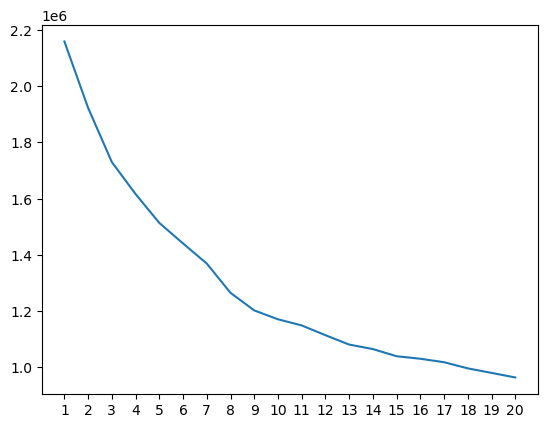

In [33]:
import matplotlib.pyplot as plt
plt.plot(range(1,21),obj)
plt.xticks(range(1,21))

Observe how the objective initially decreases sharply. The decrease slows down around cluster 8. This is consistent with our previous observation from above that the dataset displays several clusters, but not quite 10 perfect clusters.  